In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import matplotlib.pyplot as plt
import seaborn as sns
import data_processing
import random
import tensorflow as tf
import os
import shap

c:\Users\juble\miniconda3\envs\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
import gc
gc.collect()

8588

In [3]:
# Load the .npz file
#save_dir = "/Volumes/USB DRIVE/MPhys Project Data"
save_dir = "E:\MPhys Project Data"
data = np.load(os.path.join(save_dir, "data_1.npz"))
features = data["features"]
labels = data["labels"]
feature_date_indices = data["feature_date_indices"]

In [4]:
features = features.astype('float32')
labels = labels.astype('int32')
feature_date_indices = feature_date_indices.astype('int32')

In [5]:
n_profiles = features.shape[1]
n_altitudes = 150
n_features = features.shape[3] - 1

In [6]:
labels.shape
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{0: 124340, 1: 854}


In [7]:
from keras import layers, models
from tensorflow.keras.layers import Layer
from keras.optimizers import Adam
from keras.regularizers import l2


In [42]:
valid_indices = np.where(labels == 0)[0]

bad_indices = np.where(labels == 1)[0]

X_train_clean = features[valid_indices]

X_test_clean = features[bad_indices]

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_val = train_test_split(X_train_clean, test_size = 0.2, random_state = 42, shuffle = True)

In [43]:
from sklearn.utils import shuffle
X_test = shuffle(X_test_clean, random_state = 42)

In [ ]:
X_train = X_train[..., :-1]
X_val = X_val [..., :-1]
X_test = X_test[..., :-1]

In [ ]:
import gc
gc.collect()

In [56]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

# **Contextual Variational Autoencoder (VAE)**
class ContextualVAE(Model):
    def __init__(self, n_profiles, n_altitudes, n_features, latent_dim=32):
        super(ContextualVAE, self).__init__()

        self.n_profiles = n_profiles
        self.n_altitudes = n_altitudes
        self.n_features = n_features
        self.latent_dim = latent_dim

        # **ENCODER**
        self.encoder_cnn = layers.TimeDistributed(layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'))
        self.encoder_pool = layers.TimeDistributed(layers.MaxPooling1D(pool_size=2))
        self.encoder_flatten = layers.TimeDistributed(layers.Flatten())  # Flatten spatial dimensions before LSTM
        self.encoder_lstm = layers.LSTM(128, return_sequences=False)  # LSTM expects (batch_size, timesteps, features)

        # **Latent variables**
        self.mu_layer = layers.Dense(latent_dim, name="mu")
        self.log_var_layer = layers.Dense(latent_dim, name="log_var")

        # **DECODER**
        self.decoder_fc = layers.Dense(n_profiles * n_altitudes * n_features, activation='relu')
        self.decoder_reshape = layers.Reshape((n_profiles, n_altitudes, n_features))
        self.decoder_cnn = layers.TimeDistributed(layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'))
        self.decoder_output = layers.TimeDistributed(layers.Conv1D(n_features, kernel_size=3, activation='sigmoid', padding='same'))

    def encode(self, x):
        x = self.encoder_cnn(x)
        x = self.encoder_pool(x)
        x = self.encoder_flatten(x)  # Ensure we remove extra spatial dimensions before LSTM
        x = self.encoder_lstm(x)
        x = layers.Flatten()(x)  # Fully flatten before latent space
        mu, log_var = self.mu_layer(x), self.log_var_layer(x)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        epsilon = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * epsilon

    def decode(self, z):
        x = self.decoder_fc(z)
        x = self.decoder_reshape(x)
        x = self.decoder_cnn(x)
        x = self.decoder_output(x)
        return x

    def call(self, inputs):
        mu, log_var = self.encode(inputs)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decode(z)
        return reconstructed, mu, log_var  # Return all components for proper loss computation

In [57]:
# **VAE Loss Function**
def vae_loss(y_true, y_pred, mu, log_var):
    reconstruction_loss = tf.reduce_mean(tf.keras.losses.mean_squared_error(y_true, y_pred))
    kl_loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))
    return reconstruction_loss + kl_loss, reconstruction_loss, kl_loss

In [58]:
# **Custom Training Class for VAE**
class VAETrainer(tf.keras.Model):
    def __init__(self, vae):
        super(VAETrainer, self).__init__()
        self.vae = vae
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            reconstructed, mu, log_var = self.vae(data)
            total_loss, recon_loss, kl_loss = vae_loss(data, reconstructed, mu, log_var)

        grads = tape.gradient(total_loss, self.vae.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.vae.trainable_variables))
        
        # Update loss trackers
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        reconstructed, mu, log_var = self.vae(data)
        total_loss, recon_loss, kl_loss = vae_loss(data, reconstructed, mu, log_var)

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

In [59]:
# **Define Model**
n_profiles, n_altitudes, n_features = 5, 150, 11  # Adjust based on dataset
vae = ContextualVAE(n_profiles, n_altitudes, n_features)
vae_trainer = VAETrainer(vae)

# **Compile with Custom Training Step**
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
vae_trainer.compile(optimizer=optimizer)

# **Train the Model**
history = vae_trainer.fit(X_train, epochs=80, batch_size=32, validation_data=(X_val,))

Epoch 1/80
3109/3109 [==============================] - 17s 5ms/step - loss: 0.3433 - reconstruction_loss: 0.3279 - kl_loss: 0.0028 - val_loss: 0.3262 - val_reconstruction_loss: 0.3207 - val_kl_loss: 0.0055
Epoch 2/80
3109/3109 [==============================] - 12s 4ms/step - loss: 0.3257 - reconstruction_loss: 0.3182 - kl_loss: 0.0071 - val_loss: 0.3237 - val_reconstruction_loss: 0.3140 - val_kl_loss: 0.0096
Epoch 3/80
3109/3109 [==============================] - 12s 4ms/step - loss: 0.3234 - reconstruction_loss: 0.3120 - kl_loss: 0.0112 - val_loss: 0.3233 - val_reconstruction_loss: 0.3109 - val_kl_loss: 0.0124
Epoch 4/80
3109/3109 [==============================] - 12s 4ms/step - loss: 0.3231 - reconstruction_loss: 0.3090 - kl_loss: 0.0138 - val_loss: 0.3228 - val_reconstruction_loss: 0.3077 - val_kl_loss: 0.0150
Epoch 5/80
3109/3109 [==============================] - 12s 4ms/step - loss: 0.3224 - reconstruction_loss: 0.3071 - kl_loss: 0.0153 - val_loss: 0.3227 - val_reconstruction_

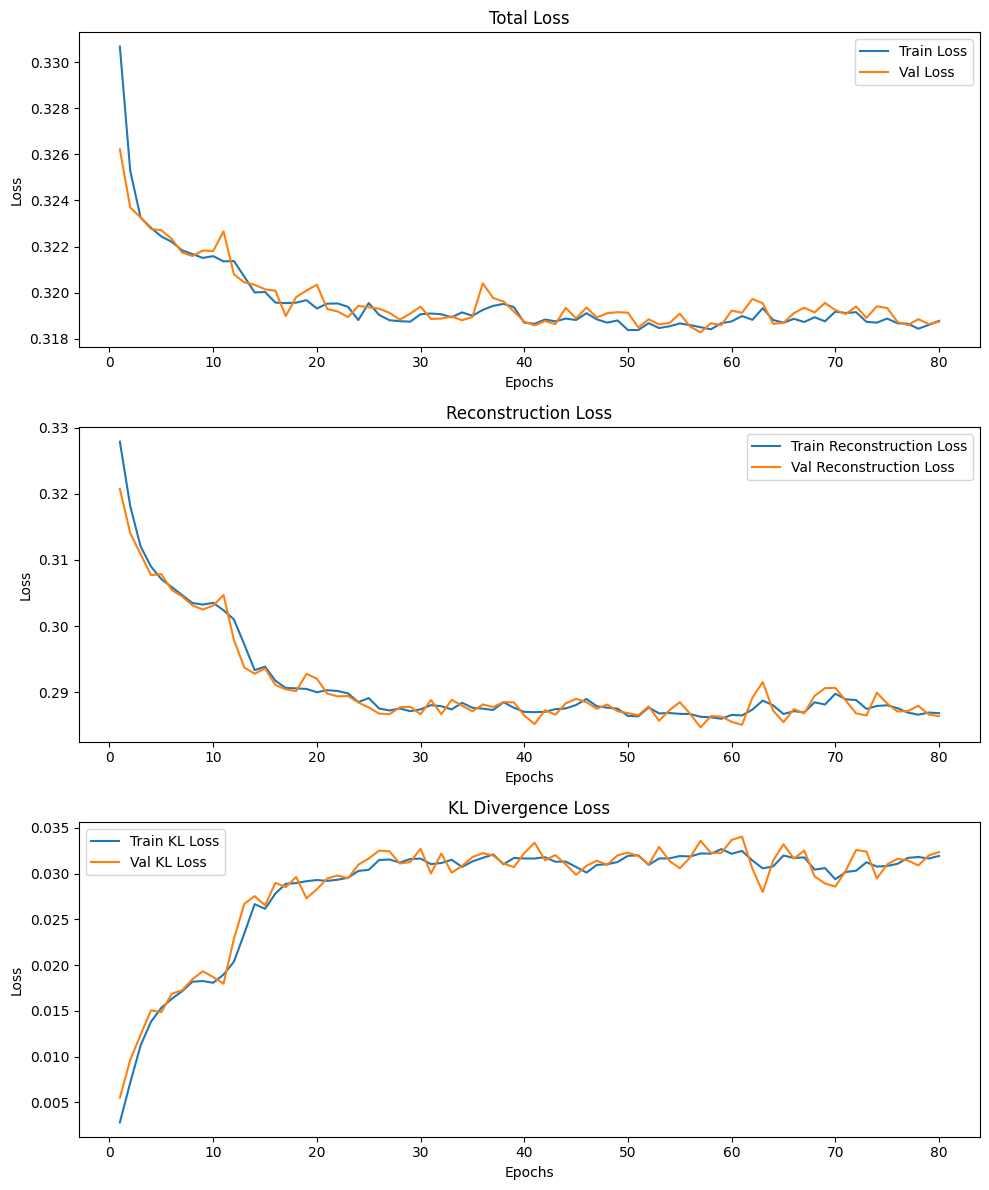

In [60]:
import matplotlib.pyplot as plt

# Extract loss history
loss = history.history["loss"]
val_loss = history.history["val_loss"]
recon_loss = history.history["reconstruction_loss"]
val_recon_loss = history.history["val_reconstruction_loss"]
kl_loss = history.history["kl_loss"]
val_kl_loss = history.history["val_kl_loss"]
epochs = range(1, len(loss) + 1)

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# **Plot Total Loss**
axes[0].plot(epochs, loss, label="Train Loss")
axes[0].plot(epochs, val_loss, label="Val Loss")
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# **Plot Reconstruction Loss**
axes[1].plot(epochs, recon_loss, label="Train Reconstruction Loss")
axes[1].plot(epochs, val_recon_loss, label="Val Reconstruction Loss")
axes[1].set_title("Reconstruction Loss")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

# **Plot KL Loss**
axes[2].plot(epochs, kl_loss, label="Train KL Loss")
axes[2].plot(epochs, val_kl_loss, label="Val KL Loss")
axes[2].set_title("KL Divergence Loss")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.tight_layout()
plt.show()

In [61]:
# Get reconstructed output
reconstructed, _, _ = vae(X_test)

# Compute Mean Squared Error (MSE) per profile
reconstruction_errors = tf.reduce_mean(tf.square(X_test - reconstructed), axis=[1, 2, 3])

# Set threshold (e.g., 95th percentile)
threshold = np.percentile(reconstruction_errors, 95)

# Flag outliers
outliers = reconstruction_errors > threshold
print("Outliers detected:", np.sum(outliers),
        "Total Outliers:", np.shape(X_test)[0]
)

Outliers detected: 43 Total Outliers: 854
